## Disciplina VIS101: Fundamentos em Visão Computacional

### Segmentação por cor em vídeo

Aplicação da segmentação por faixa de cor, apresentada no notebook de espaços de cor, a um vídeo com objetos de cores distintas. O objetivo é isolar apenas as cores de interesse.

### Preparação

In [1]:
import os
import urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.figsize': (10, 5), 'font.size': 12})

os.makedirs('../videos', exist_ok=True)

url = "https://raw.githubusercontent.com/carlosfab/visao-computacional/main/vis101/segmentacao-por-cor/data/chuva-bolas-3cores.mp4"
destino = "../videos/chuva-bolas-3cores.mp4"

urllib.request.urlretrieve(url, destino)
print("Vídeo baixado com sucesso!")

Vídeo baixado com sucesso!


### Um quadro do vídeo

`CAP_PROP_POS_FRAMES` posiciona a leitura no quadro desejado. O quadro retornado é uma matriz BGR.

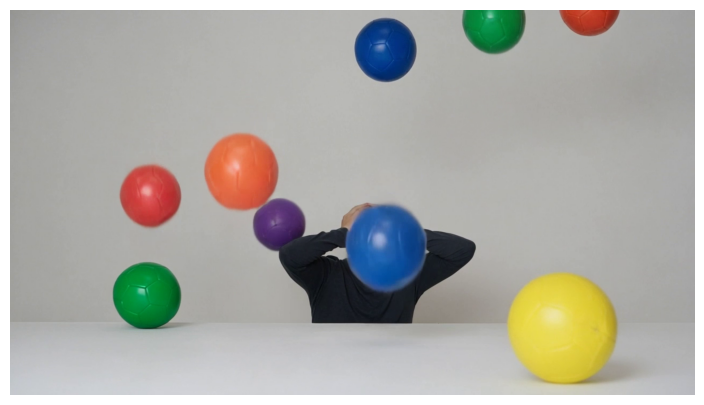

In [2]:
cap = cv2.VideoCapture('../videos/chuva-bolas-3cores.mp4')
cap.set(cv2.CAP_PROP_POS_FRAMES, 60)
ok, frame = cap.read()
cap.release()

plt.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Segmentação de uma cor

Conversão para HSV e seleção por faixa com `cv2.inRange`. Os limites mínimos de saturação e valor excluem o fundo, de baixa saturação.

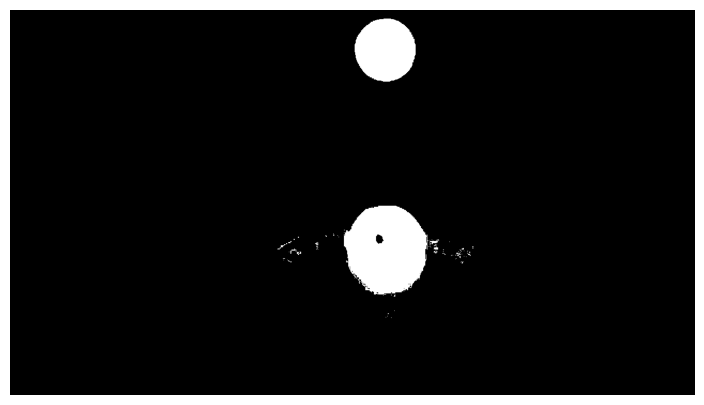

In [3]:
hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)

azul = cv2.inRange(hsv, (95, 80, 40), (130, 255, 255))
plt.imshow(azul, cmap='gray')
plt.axis('off')
plt.show()

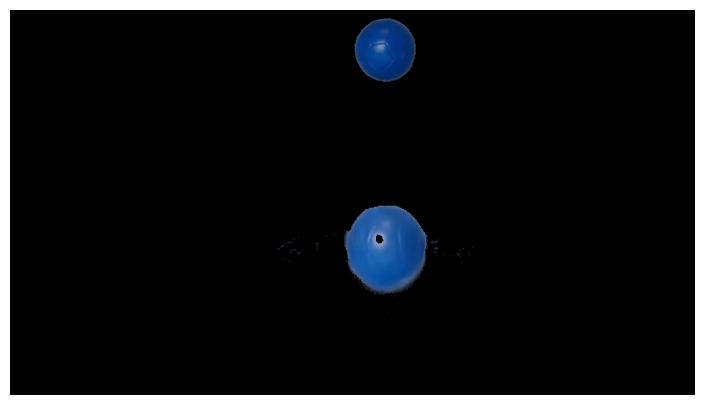

In [4]:
res = cv2.bitwise_and(frame, frame, mask=azul)
plt.imshow(cv2.cvtColor(res, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Múltiplas cores

Uma faixa por cor; as máscaras são combinadas com `cv2.bitwise_or`. A abertura morfológica remove ruído pontual.

In [5]:
faixas = {
    'amarelo': ((20, 65, 65), (35, 255, 255)),
    'verde':   ((40, 65, 65), (85, 255, 255)),
    'azul':    ((95, 65, 65), (130, 255, 255)),
}

In [6]:
print(hsv.shape[:])

(720, 1280, 3)


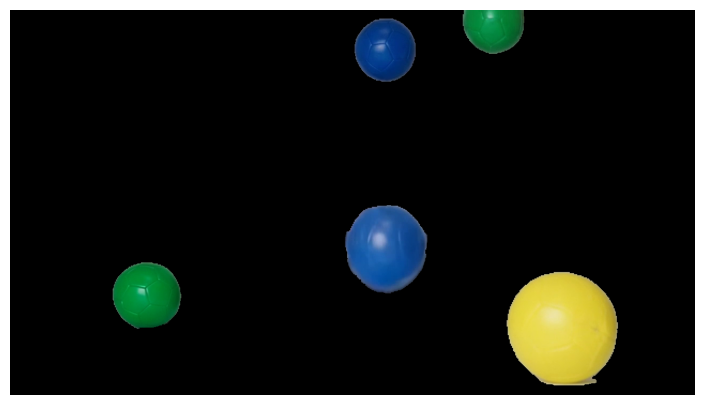

In [7]:
mask = np.zeros(hsv.shape[:2], np.uint8)
for lo, hi in faixas.values():
    mask = cv2.bitwise_or(mask, cv2.inRange(hsv, np.array(lo), np.array(hi)))
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))

seg = cv2.bitwise_and(frame, frame, mask=mask)
plt.imshow(cv2.cvtColor(seg, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

### Calibração de faixas

Os limites de uma faixa são determinados empiricamente. Com `ipywidgets`, os limites tornam-se controles deslizantes e a máscara é recalculada a cada ajuste. Exercício: determinar a faixa da bola vermelha, considerando a posição do vermelho no eixo H.

In [8]:
from ipywidgets import interact

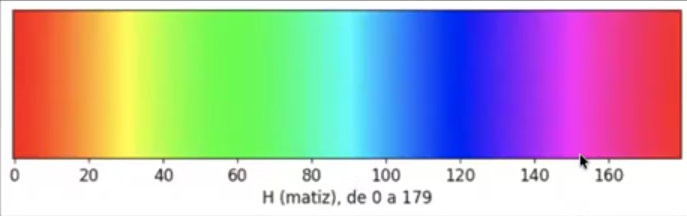

In [ ]:
def testar(h_min, h_max, s_min, v_min):
    m = cv2.inRange(hsv, (h_min, s_min, v_min), (h_max, 255, 255))
    plt.imshow(m, cmap='gray')
    plt.axis('off')
    plt.show()

interact(testar, h_min=(0, 179, 1), h_max=(0, 179, 1),
         s_min=(0, 255, 1), v_min=(0, 255, 1));

interactive(children=(IntSlider(value=89, description='h_min', max=179), IntSlider(value=89, description='h_ma…

### Aplicação ao vídeo

O procedimento é encapsulado em uma função aplicável a cada quadro.

In [10]:
def segmentar(frame):
    hsv = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
    m = np.zeros(hsv.shape[:2], np.uint8)
    for lo, hi in faixas.values():
        m = cv2.bitwise_or(m, cv2.inRange(hsv, np.array(lo), np.array(hi)))
    m = cv2.morphologyEx(m, cv2.MORPH_OPEN, np.ones((5, 5), np.uint8))
    return cv2.bitwise_and(frame, frame, mask=m)

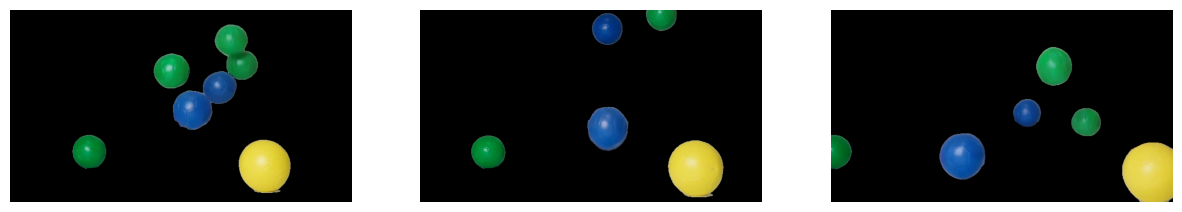

In [11]:
cap = cv2.VideoCapture('../videos/chuva-bolas-3cores.mp4')
quadros = []
for i in [30, 60, 90]:
    cap.set(cv2.CAP_PROP_POS_FRAMES, i)
    ok, f = cap.read()
    quadros.append(f)
cap.release()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, quadros):
    ax.imshow(cv2.cvtColor(segmentar(f), cv2.COLOR_BGR2RGB))
    ax.axis('off')
plt.show()